# 🔍 Model Interpretability & Explainable AI (XAI) Dashboard
## 5G Network Slice Selection — Transparent Decision-Making for Network Operators

**Business Objective:**  
Network operators need to *trust* AI-driven slice assignment decisions before deploying them in  
production. This notebook builds a **transparent Random Forest classifier** for slice selection  
and wraps it in a full XAI suite — global feature importance, SHAP explanations, LIME  
instance-level explanations, decision paths, and a live interactive operator dashboard.

> **Target variable:** `slice Type` — which 5G network slice was assigned  
> - **1 — eMBB** (Enhanced Mobile Broadband): high-throughput, moderate latency  
> - **2 — URLLC** (Ultra-Reliable Low-Latency): mission-critical, strict QoS  
> - **3 — mIoT** (Massive IoT): low-power, high-density, relaxed latency  

**Input features (4 non-redundant base columns):**  
`Time`, `Packet Loss Rate`, `Packet delay`, `LTE/5g Category`

## XAI Methods Used

| Method | Scope | What it answers |
|---|---|---|
| RF feature importance (MDI) | Global | Which features matter most overall? |
| Permutation importance | Global | How much does AUC drop when a feature is shuffled? |
| SHAP TreeExplainer | Global + Local | How does each feature push a prediction up or down? |
| SHAP summary & beeswarm | Global | Feature value → SHAP value patterns |
| SHAP dependence plots | Global | Non-linear feature effects |
| SHAP force plots | Local | Full decomposition for one prediction |
| LIME | Local | Locally-faithful linear approximation |
| Decision path trace | Local | Exact tree path for one sample |
| Interactive dashboard | Operational | Operator-facing panel for live decisions |

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Feature Engineering](#2)
3. [Model Training & Validation](#3)
4. [Hyperparameter Tuning](#4)
5. [Global Explainability — Feature Importance](#5)
6. [Global Explainability — SHAP Summary](#6)
7. [Global Explainability — SHAP Dependence Plots](#7)
8. [Local Explainability — SHAP Force Plots](#8)
9. [Local Explainability — LIME](#9)
10. [Local Explainability — Decision Path Trace](#10)
11. [XAI Operator Dashboard](#11)
12. [Summary & Operator Takeaways](#12)


<a id='1'></a>
---
## 1. Setup & Data Loading

In [2]:
pip install lime

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283840 sha256=e604132900b325d70e3d2b0b68b3ef2378668630f2e76963f7c8dc9746bcc71e
  Stored in directory: c:\users\pc_lenovo\appdata\local\pip\cache\wheels\e7\5d\0e\4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, roc_curve, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn import tree as sklearn_tree

import shap
import lime
import lime.lime_tabular

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SLICE_NAMES  = {1: 'eMBB', 2: 'URLLC', 3: 'mIoT'}
SLICE_COLORS = {1: '#3498db', 2: '#e74c3c', 3: '#2ecc71'}
SLICE_DESC   = {
    1: 'Enhanced Mobile Broadband — high throughput, moderate latency',
    2: 'Ultra-Reliable Low-Latency — mission-critical, strict QoS',
    3: 'Massive IoT — low-power, high-density, relaxed latency',
}

print('Libraries loaded ✔')
print(f'  shap  {shap.__version__}')
import pkg_resources
print(f"  lime  {pkg_resources.get_distribution('lime').version}")


Libraries loaded ✔
  shap  0.51.0
  lime  0.2.0.1


In [8]:
train_raw = pd.read_csv('train_prepared_5g.csv')
test_raw  = pd.read_csv('test_prepared_5g.csv')

print(f'Train : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns')
print(f'Test  : {test_raw.shape[0]:,} rows × {test_raw.shape[1]} columns')
print()
print('Slice distribution (train):')
for k, v in train_raw['slice Type'].value_counts().sort_index().items():
    pct = v / len(train_raw) * 100
    print(f'  {SLICE_NAMES[k]} (Type {k}): {v:,}  ({pct:.1f}%)  — {SLICE_DESC[k]}')


Train : 8,958 rows × 30 columns
Test  : 8,960 rows × 29 columns

Slice distribution (train):
  eMBB (Type 1): 4,772  (53.3%)  — Enhanced Mobile Broadband — high throughput, moderate latency
  URLLC (Type 2): 2,088  (23.3%)  — Ultra-Reliable Low-Latency — mission-critical, strict QoS
  mIoT (Type 3): 2,098  (23.4%)  — Massive IoT — low-power, high-density, relaxed latency


<a id='2'></a>
---
## 2. Feature Engineering

Only the 4 non-redundant base features are used to avoid artificially inflated scores from  
correlated pre-engineered columns. Nine interpretable features are derived:

| Feature | Formula | Operator-readable meaning |
|---|---|---|
| `time_sin`, `time_cos` | cyclic hour encoding | Time-of-day position (avoids 23→0 discontinuity) |
| `is_peak` | 1 if 8–10 h or 18–21 h | Network congestion window flag |
| `log_plr` | log₁₀(PLR) | Packet loss severity (log scale) |
| `log_delay` | log₁₀(delay ms) | Latency level (log scale) |
| `plr_x_delay` | log_plr × log_delay | Joint QoS stress signal |
| `lte5g_cat` | bearer category (1–22) | 5G NR bearer class |
| `high_delay` | delay ≥ 150 ms | Hard latency SLA breach flag |
| `high_plr` | PLR ≥ 1e-2 | Hard loss SLA breach flag |


In [9]:
BASE_FEATURES = ['Time', 'Packet Loss Rate', 'Packet delay', 'LTE/5g Category']
FEAT_NAMES    = ['time_sin', 'time_cos', 'is_peak', 'log_plr', 'log_delay',
                 'plr_x_delay', 'lte5g_cat', 'high_delay', 'high_plr']

# Human-readable labels for dashboards
FEAT_LABELS = {
    'time_sin'   : 'Time (sin)',
    'time_cos'   : 'Time (cos)',
    'is_peak'    : 'Peak Hour Flag',
    'log_plr'    : 'Log Packet Loss Rate',
    'log_delay'  : 'Log Packet Delay',
    'plr_x_delay': 'PLR × Delay (joint stress)',
    'lte5g_cat'  : 'LTE/5G Category',
    'high_delay' : 'High Delay Flag (≥150ms)',
    'high_plr'   : 'High PLR Flag (≥1%)',
}


def engineer(df: pd.DataFrame) -> pd.DataFrame:
    """Derive 9 interpretable features from the 4 base columns."""
    t     = df['Time']
    plr   = df['Packet Loss Rate']
    delay = df['Packet delay']
    cat   = df['LTE/5g Category']
    return pd.DataFrame({
        'time_sin'   : np.sin(2 * np.pi * t / 24),
        'time_cos'   : np.cos(2 * np.pi * t / 24),
        'is_peak'    : (((t >= 8) & (t <= 10)) | ((t >= 18) & (t <= 21))).astype(int),
        'log_plr'    : np.log10(plr.clip(1e-9)),
        'log_delay'  : np.log10(delay),
        'plr_x_delay': np.log10(plr.clip(1e-9)) * np.log10(delay),
        'lte5g_cat'  : cat.astype(float),
        'high_delay' : (delay >= 150).astype(int),
        'high_plr'   : (plr >= 1e-2).astype(int),
    }, index=df.index)


X_all = engineer(train_raw)
y_all = train_raw['slice Type'].values
X_te  = engineer(test_raw)

scaler   = StandardScaler()
Xs_all   = scaler.fit_transform(X_all)
Xte_s    = scaler.transform(X_te)

X_train, X_val, y_train, y_val = train_test_split(
    Xs_all, y_all, test_size=0.2, stratify=y_all, random_state=RANDOM_STATE
)

print(f'Feature matrix: {X_all.shape[1]} features × {X_all.shape[0]:,} samples')
print(f'Train split : {len(y_train):,}  |  Val split : {len(y_val):,}')
print(f'\nFeature summary (train split, unscaled):')
X_all.describe().round(3)


Feature matrix: 9 features × 8,958 samples
Train split : 7,166  |  Val split : 1,792

Feature summary (train split, unscaled):


,time_sin,time_cos,is_peak,log_plr,log_delay,plr_x_delay,lte5g_cat,high_delay,high_plr
count,8958.000,8958.000,8958.000,8958.000,8958.000,8958.000,8958.000,8958.000,8958.000
mean,-0.001,0.000,0.292,-4.060,1.812,-6.939,10.971,0.276,0.281
std,0.707,0.707,0.455,1.784,0.520,3.416,6.062,0.447,0.450
min,-1.000,-1.000,0.000,-6.000,1.000,-14.863,1.000,0.000,0.000
25%,-0.707,-0.707,0.000,-6.000,1.699,-6.528,6.000,0.000,0.000
50%,0.000,0.000,0.000,-3.000,1.875,-6.000,11.000,0.000,0.000
75%,0.707,0.707,1.000,-2.000,2.176,-4.954,16.000,1.000,1.000
max,1.000,1.000,1.000,-2.000,2.477,-3.398,22.000,1.000,1.000


<a id='3'></a>
---
## 3. Model Training & Validation

**Why Random Forest for XAI?**  
- TreeExplainer (SHAP) gives *exact* Shapley values in polynomial time for tree ensembles
- Decision paths are traceable to individual feature thresholds
- MDI importance is directly readable by operators as "this feature caused this many splits"
- Robust to feature scale (though we still standardise for LIME's local linear model)


In [10]:
# Initial model with reasonable defaults — tuning follows in Section 4
rf_base = RandomForestClassifier(
    n_estimators=100, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1
)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_val)
print('── Baseline Random Forest ──')
print(classification_report(y_val, y_pred_base,
      target_names=[SLICE_NAMES[k] for k in sorted(SLICE_NAMES)]))


── Baseline Random Forest ──
              precision    recall  f1-score   support

        eMBB       0.93      0.94      0.93       954
       URLLC       0.85      0.85      0.85       418
        mIoT       1.00      1.00      1.00       420

    accuracy                           0.93      1792
   macro avg       0.93      0.93      0.93      1792
weighted avg       0.93      0.93      0.93      1792



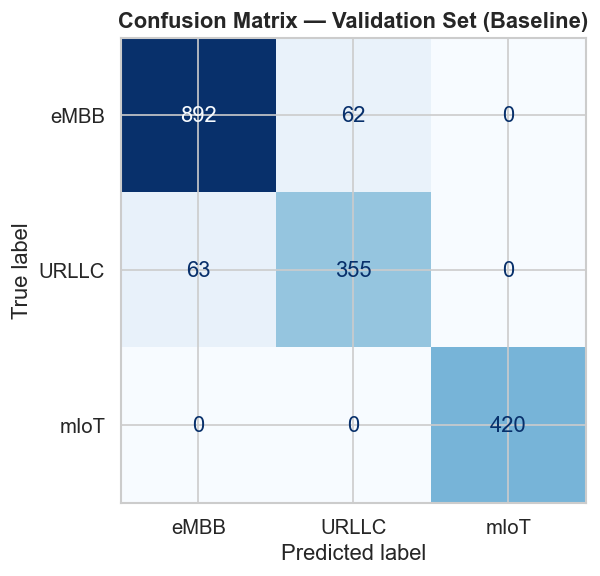

In [11]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[SLICE_NAMES[k] for k in [1,2,3]])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Validation Set (Baseline)', fontweight='bold')
plt.tight_layout()
plt.show()


In [12]:
# Stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_f1  = cross_val_score(rf_base, Xs_all, y_all, cv=cv, scoring='f1_macro',    n_jobs=-1)
cv_acc = cross_val_score(rf_base, Xs_all, y_all, cv=cv, scoring='accuracy',    n_jobs=-1)

print('5-Fold Cross-Validation (baseline RF):')
print(f'  F1-macro  : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')
print(f'  Accuracy  : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}')
print(f'  Per-fold F1: {cv_f1.round(4).tolist()}')


5-Fold Cross-Validation (baseline RF):
  F1-macro  : 0.9239  ± 0.0056
  Accuracy  : 0.9262  ± 0.0051
  Per-fold F1: [0.9159, 0.9289, 0.9293, 0.9267, 0.9187]


<a id='4'></a>
---
## 4. Hyperparameter Tuning

Grid search over the three most impactful Random Forest hyperparameters,  
using 3-fold CV F1-macro as the objective to avoid overfitting to any single split.


In [13]:
param_grid = [
    {'n_estimators': n, 'max_depth': d}
    for n in [100, 200]
    for d in [8, 12, None]
]

tuning_results = []
for params in param_grid:
    m   = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    f1  = cross_val_score(m, Xs_all, y_all, cv=3, scoring='f1_macro', n_jobs=-1).mean()
    acc = cross_val_score(m, Xs_all, y_all, cv=3, scoring='accuracy', n_jobs=-1).mean()
    tuning_results.append({**params, 'CV F1-macro': round(f1, 4), 'CV Accuracy': round(acc, 4)})

tuning_df = pd.DataFrame(tuning_results).sort_values('CV F1-macro', ascending=False)
print(tuning_df.to_string(index=False))


 n_estimators  max_depth  CV F1-macro  CV Accuracy
          100        8.0       0.9272       0.9294
          200        8.0       0.9263       0.9287
          100       12.0       0.9119       0.9145
          200       12.0       0.9106       0.9133
          200        NaN       0.9085       0.9110
          100        NaN       0.9083       0.9110


In [14]:
best_row    = tuning_df.iloc[0]
best_params = {'n_estimators': int(best_row['n_estimators']),
               'max_depth'   : None if pd.isna(best_row['max_depth'])
                               else int(best_row['max_depth'])}

print(f'Best hyperparameters: {best_params}')
print(f'  CV F1-macro : {best_row["CV F1-macro"]:.4f}')
print(f'  CV Accuracy : {best_row["CV Accuracy"]:.4f}')

# Train final model on full training split
rf = RandomForestClassifier(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_val)
y_proba = rf.predict_proba(X_val)

print()
print('── Final Tuned Model — Validation Results ──')
print(classification_report(y_val, y_pred,
      target_names=[SLICE_NAMES[k] for k in sorted(SLICE_NAMES)]))


Best hyperparameters: {'n_estimators': 100, 'max_depth': 8}
  CV F1-macro : 0.9272
  CV Accuracy : 0.9294

── Final Tuned Model — Validation Results ──
              precision    recall  f1-score   support

        eMBB       0.93      0.94      0.93       954
       URLLC       0.85      0.85      0.85       418
        mIoT       1.00      1.00      1.00       420

    accuracy                           0.93      1792
   macro avg       0.93      0.93      0.93      1792
weighted avg       0.93      0.93      0.93      1792



<a id='5'></a>
---
## 5. Global Explainability — Feature Importance

Two complementary global importance measures:

**MDI (Mean Decrease in Impurity)** — how often a feature is used for splits, weighted by  
the impurity reduction. Fast but biased toward high-cardinality features.

**Permutation Importance** — how much validation F1-macro drops when a feature's values  
are randomly shuffled. Model-agnostic, unbiased, but slower.


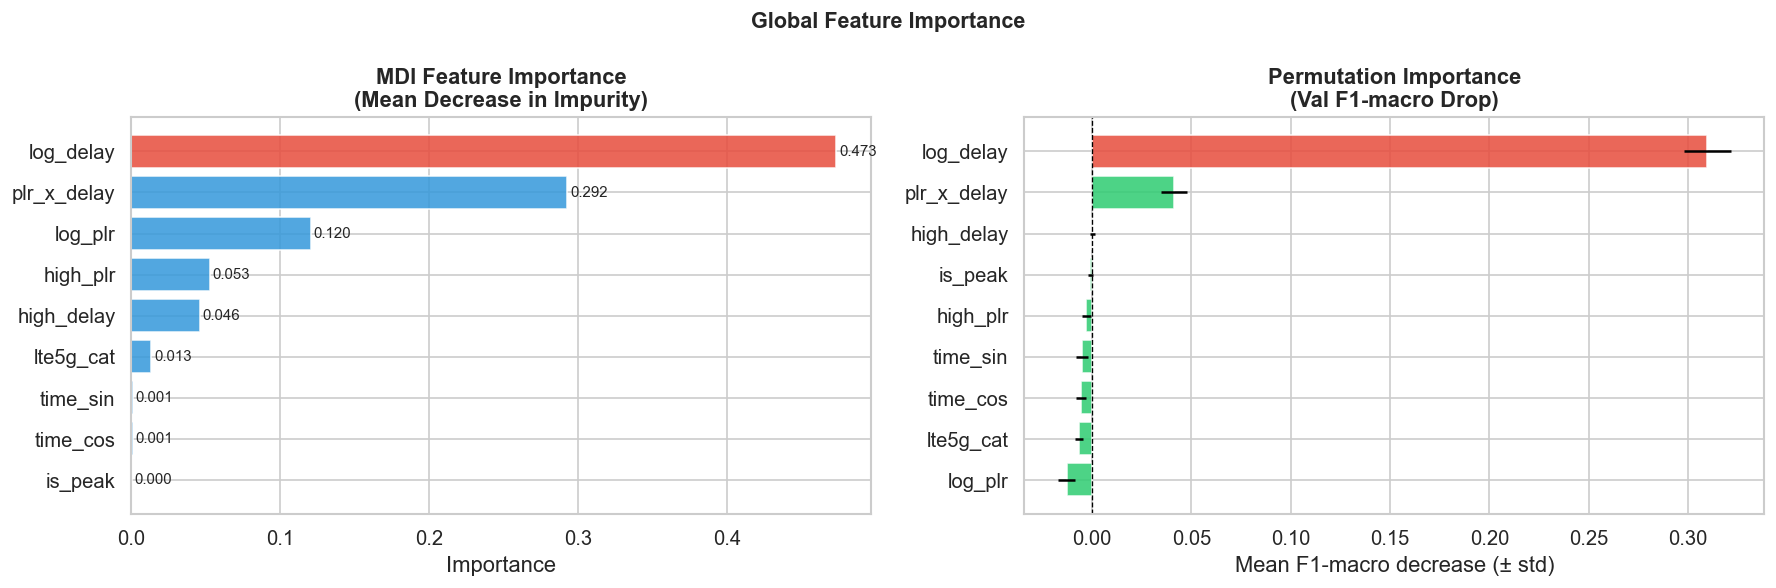

Top features by permutation importance:
  Log Packet Delay                   : +0.3097  (±0.0118)
  PLR × Delay (joint stress)         : +0.0414  (±0.0065)
  High Delay Flag (≥150ms)           : +0.0001  (±0.0012)
  Peak Hour Flag                     : -0.0008  (±0.0013)
  High PLR Flag (≥1%)                : -0.0028  (±0.0023)


In [15]:
# MDI importance
mdi_imp = pd.Series(rf.feature_importances_, index=FEAT_NAMES).sort_values(ascending=True)

# Permutation importance
perm_imp = permutation_importance(
    rf, X_val, y_val, n_repeats=15, random_state=RANDOM_STATE, scoring='f1_macro', n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature'  : FEAT_NAMES,
    'importance': perm_imp.importances_mean,
    'std'       : perm_imp.importances_std,
}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MDI
ax = axes[0]
bars = ax.barh(mdi_imp.index, mdi_imp.values,
               color=[('#e74c3c' if v == mdi_imp.max() else '#3498db') for v in mdi_imp.values],
               edgecolor='white', alpha=0.85)
ax.set_title('MDI Feature Importance\n(Mean Decrease in Impurity)', fontweight='bold')
ax.set_xlabel('Importance')
for bar, val in zip(bars, mdi_imp.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

# Permutation
ax = axes[1]
ax.barh(perm_df['feature'], perm_df['importance'],
        xerr=perm_df['std'],
        color=[('#e74c3c' if v == perm_df['importance'].max() else '#2ecc71')
               for v in perm_df['importance']],
        edgecolor='white', alpha=0.85, error_kw={'elinewidth': 1.5})
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_title('Permutation Importance\n(Val F1-macro Drop)', fontweight='bold')
ax.set_xlabel('Mean F1-macro decrease (± std)')

plt.suptitle('Global Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top features by permutation importance:')
for _, row in perm_df.sort_values('importance', ascending=False).head(5).iterrows():
    readable = FEAT_LABELS[row['feature']]
    print(f'  {readable:35s}: {row["importance"]:+.4f}  (±{row["std"]:.4f})')


<a id='6'></a>
---
## 6. Global Explainability — SHAP Summary

**SHAP (SHapley Additive exPlanations)** decomposes each prediction into additive  
feature contributions based on cooperative game theory. For tree ensembles, TreeExplainer  
computes *exact* Shapley values efficiently.

For a multiclass problem, we obtain one SHAP value per (sample, feature, class).  
A positive SHAP value means that feature *pushed the model toward* that class.


In [16]:
# Compute SHAP values on validation set
explainer  = shap.TreeExplainer(rf)
shap_vals  = explainer.shap_values(X_val)   # shape: (n_samples, n_features, n_classes)
# shap_vals[:,:,0] → eMBB contributions, [:,:,1] → URLLC, [:,:,2] → mIoT

print(f'SHAP values computed  ✔   shape: {shap_vals.shape}')
print(f'  Axis 0 = {shap_vals.shape[0]:,} validation samples')
print(f'  Axis 1 = {shap_vals.shape[1]} features')
print(f'  Axis 2 = {shap_vals.shape[2]} slice classes')


SHAP values computed  ✔   shape: (1792, 9, 3)
  Axis 0 = 1,792 validation samples
  Axis 1 = 9 features
  Axis 2 = 3 slice classes


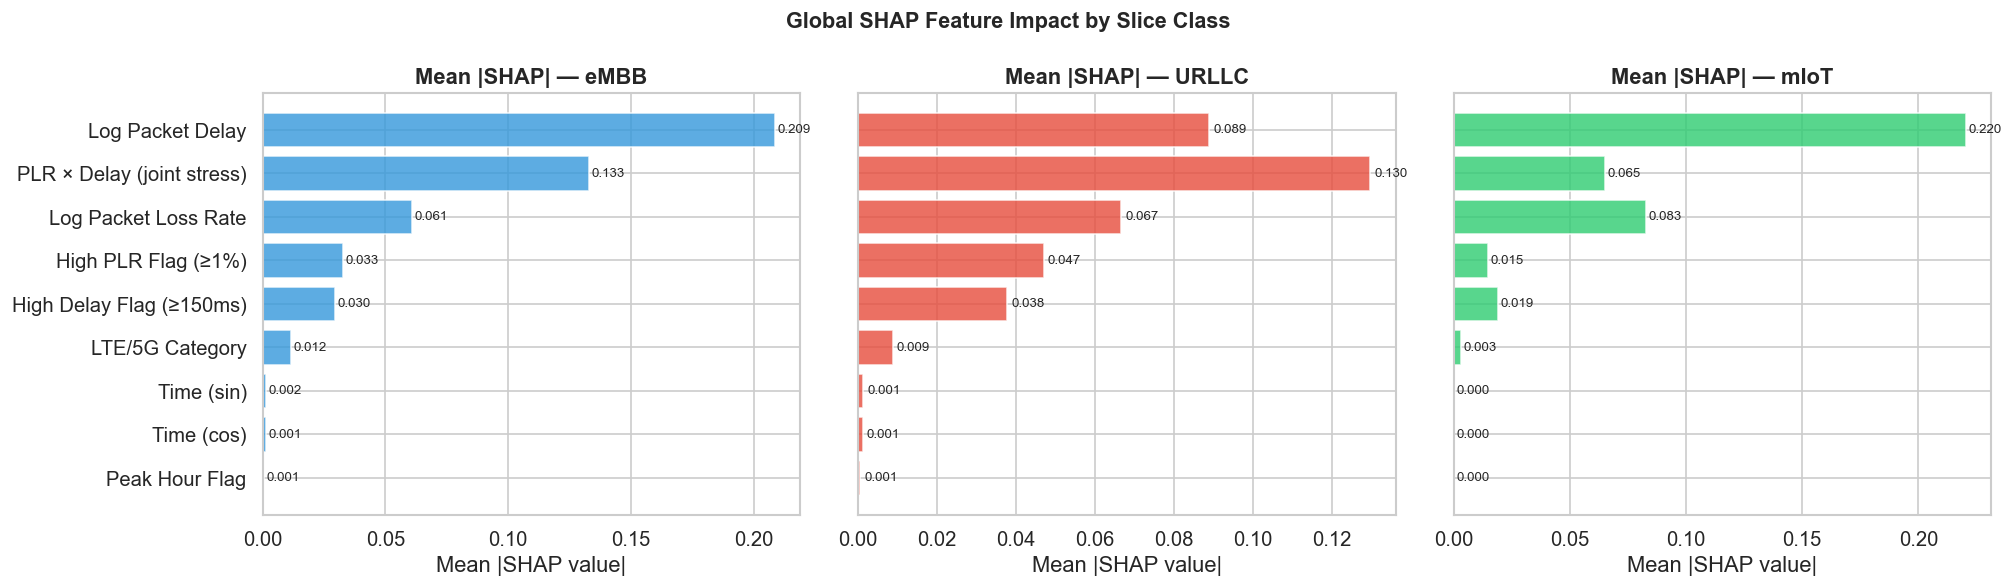

In [17]:
# Global mean |SHAP| per feature per class
mean_abs_shap = np.abs(shap_vals).mean(axis=0)   # (n_features, n_classes)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
class_labels = [SLICE_NAMES[k] for k in [1, 2, 3]]
class_colors = [SLICE_COLORS[k] for k in [1, 2, 3]]

for ci, (ax, cname, col) in enumerate(zip(axes, class_labels, class_colors)):
    vals  = mean_abs_shap[:, ci]
    order = np.argsort(vals)
    bars  = ax.barh([FEAT_LABELS[FEAT_NAMES[i]] for i in order], vals[order],
                    color=col, alpha=0.8, edgecolor='white')
    ax.set_title(f'Mean |SHAP| — {cname}', fontweight='bold')
    ax.set_xlabel('Mean |SHAP value|')
    for bar, val in zip(bars, vals[order]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Global SHAP Feature Impact by Slice Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


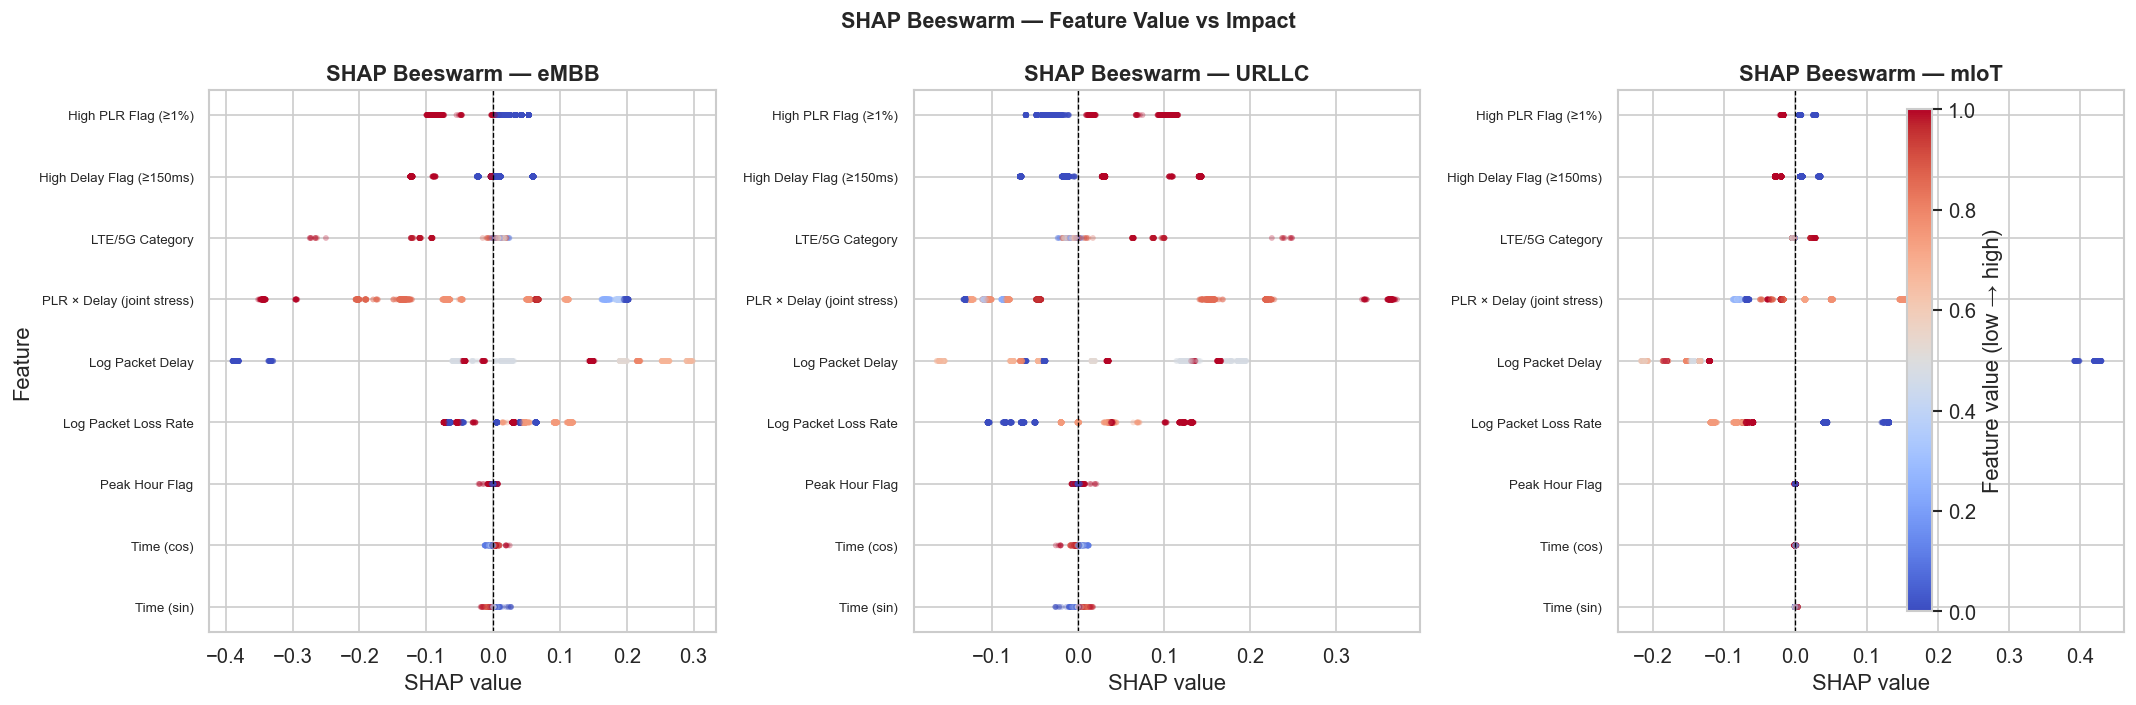

Colour = feature value: BLUE = low value, RED = high value


In [21]:
# SHAP Beeswarm plots — one per class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ci, (ax, cname) in enumerate(zip(axes, class_labels)):
    sv_cls = shap_vals[:, :, ci]
    feat_order = np.argsort(np.abs(sv_cls).mean(axis=0))[::-1]

    for fi in feat_order:
        sv = sv_cls[:, fi]
        fv = X_val[:, fi]

        # colour by feature value (low=blue, high=red)
        norm = (fv - fv.min()) / (np.ptp(fv) + 1e-9)

        ax.scatter(
            sv,
            np.full_like(sv, fi),
            c=norm,
            cmap='coolwarm',
            alpha=0.3,
            s=12,
            linewidths=0
        )

    ax.set_yticks(feat_order)
    ax.set_yticklabels([FEAT_LABELS[FEAT_NAMES[i]] for i in feat_order], fontsize=8)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f'SHAP Beeswarm — {cname}', fontweight='bold')
    ax.set_xlabel('SHAP value')
    if ci == 0:
        ax.set_ylabel('Feature')

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.015, pad=0.02,
             label='Feature value (low → high)')

plt.suptitle('SHAP Beeswarm — Feature Value vs Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Colour = feature value: BLUE = low value, RED = high value')


<a id='7'></a>
---
## 7. Global Explainability — SHAP Dependence Plots

A dependence plot shows how a single feature's value relates to its SHAP contribution  
for a given class, revealing non-linear effects and thresholds that operators can act on.


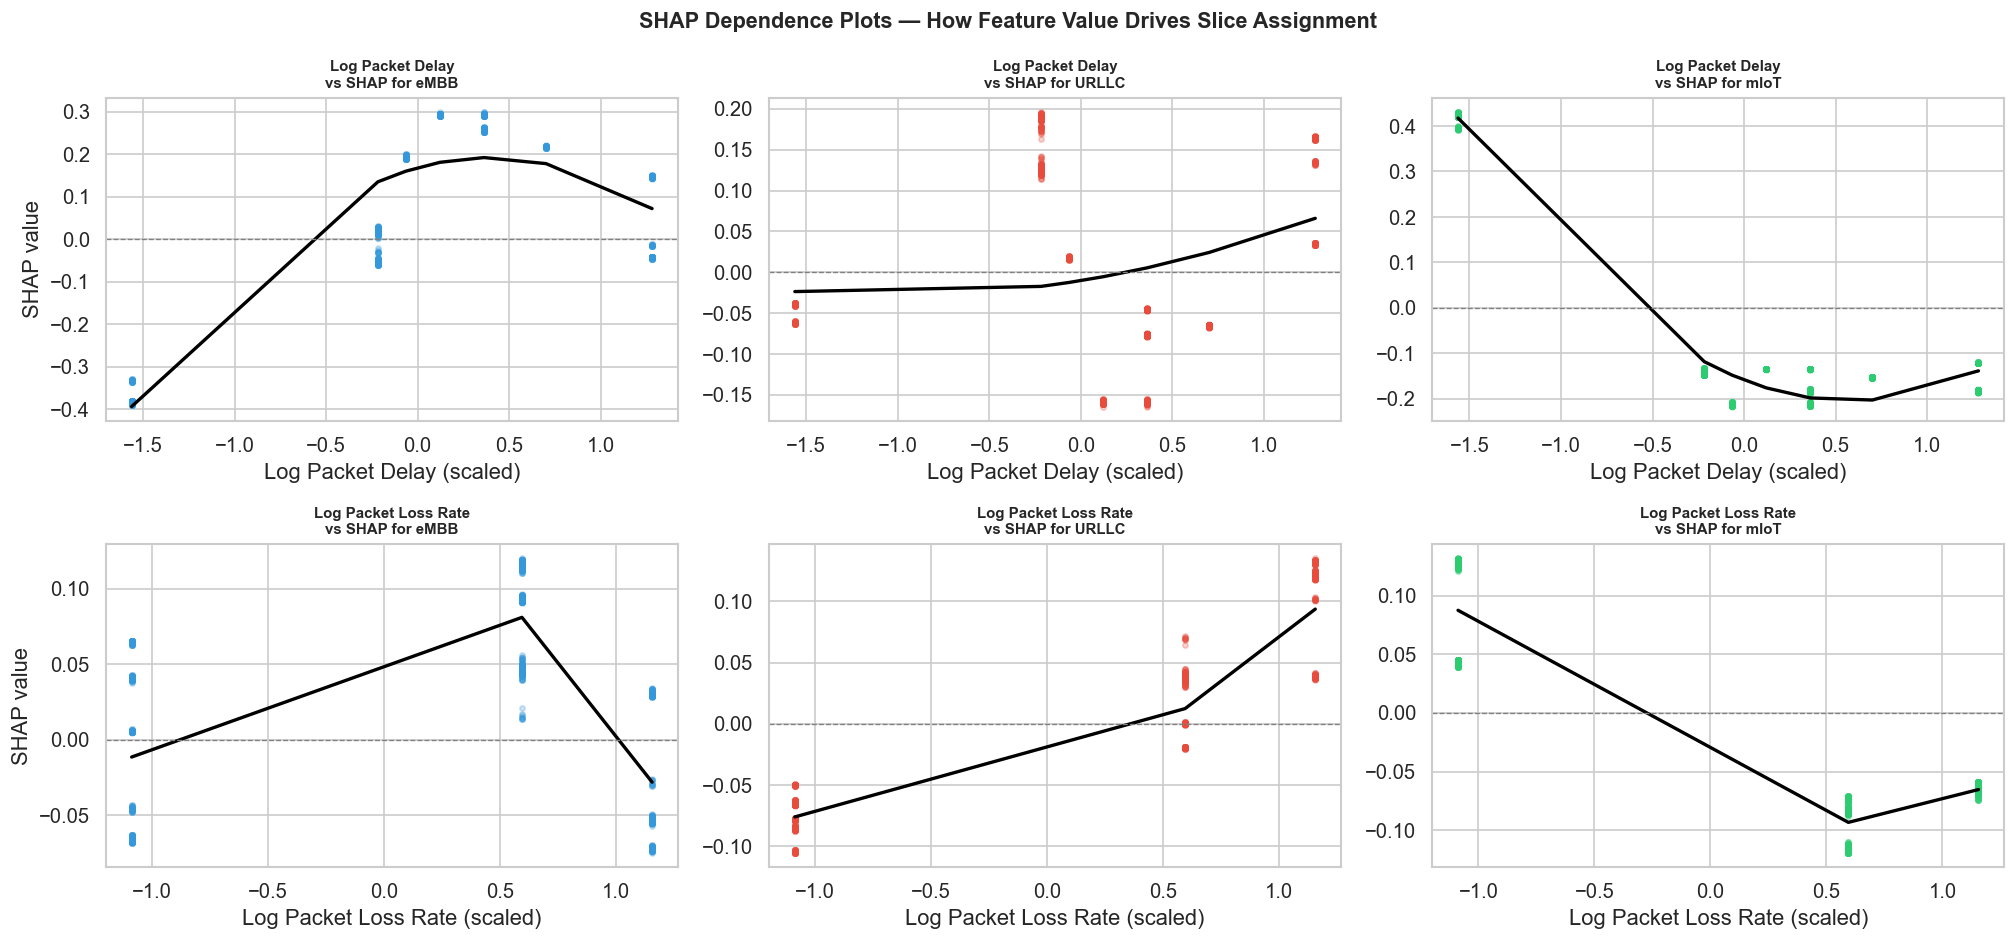

In [22]:
# Dependence plots for the top 2 features × all 3 classes
top_feats = ['log_delay', 'log_plr']

fig, axes = plt.subplots(len(top_feats), 3, figsize=(17, 8))

for ri, feat in enumerate(top_feats):
    fi   = FEAT_NAMES.index(feat)
    fraw = X_all[feat]      # unscaled original values for x-axis
    fval = X_val[:, fi]     # scaled (used for SHAP)

    for ci, (ax, cname, col) in enumerate(zip(axes[ri], class_labels, class_colors)):
        sv = shap_vals[:, fi, ci]
        sc = ax.scatter(fval, sv, c=col, alpha=0.25, s=10)
        # Trend line
        z = np.polyfit(fval, sv, 2)
        p = np.poly1d(z)
        xs_sorted = np.sort(fval)
        ax.plot(xs_sorted, p(xs_sorted), color='black', lw=2, label='trend')
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.set_title(f'{FEAT_LABELS[feat]}\nvs SHAP for {cname}', fontweight='bold', fontsize=9)
        ax.set_xlabel(f'{FEAT_LABELS[feat]} (scaled)')
        if ci == 0:
            ax.set_ylabel('SHAP value')

plt.suptitle('SHAP Dependence Plots — How Feature Value Drives Slice Assignment',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


<a id='8'></a>
---
## 8. Local Explainability — SHAP Force Plots

For each individual traffic record, we can decompose the model's prediction into  
*additive feature contributions*, starting from the base value (average model output).  
Features pushing the prediction toward a class are shown in red; those pushing away in blue.

We show **3 representative records** — one typical example of each slice class.


In [23]:
# Pick one representative from each class
sample_indices = {}
for cls in [1, 2, 3]:
    idxs = np.where(y_val == cls)[0]
    # pick a correctly predicted, high-confidence example
    proba_cls = rf.predict_proba(X_val[idxs])[:, cls - 1]
    best_i    = idxs[np.argmax(proba_cls)]
    sample_indices[cls] = best_i

print('Representative samples selected:')
for cls, idx in sample_indices.items():
    p_vec = rf.predict_proba(X_val[[idx]])[0]
    print(f'  Slice {cls} ({SLICE_NAMES[cls]}): val-idx={idx}  '
          f'proba=[eMBB:{p_vec[0]:.2f}, URLLC:{p_vec[1]:.2f}, mIoT:{p_vec[2]:.2f}]')


Representative samples selected:
  Slice 1 (eMBB): val-idx=5  proba=[eMBB:1.00, URLLC:0.00, mIoT:0.00]
  Slice 2 (URLLC): val-idx=1  proba=[eMBB:0.00, URLLC:1.00, mIoT:0.00]
  Slice 3 (mIoT): val-idx=0  proba=[eMBB:0.00, URLLC:0.00, mIoT:1.00]


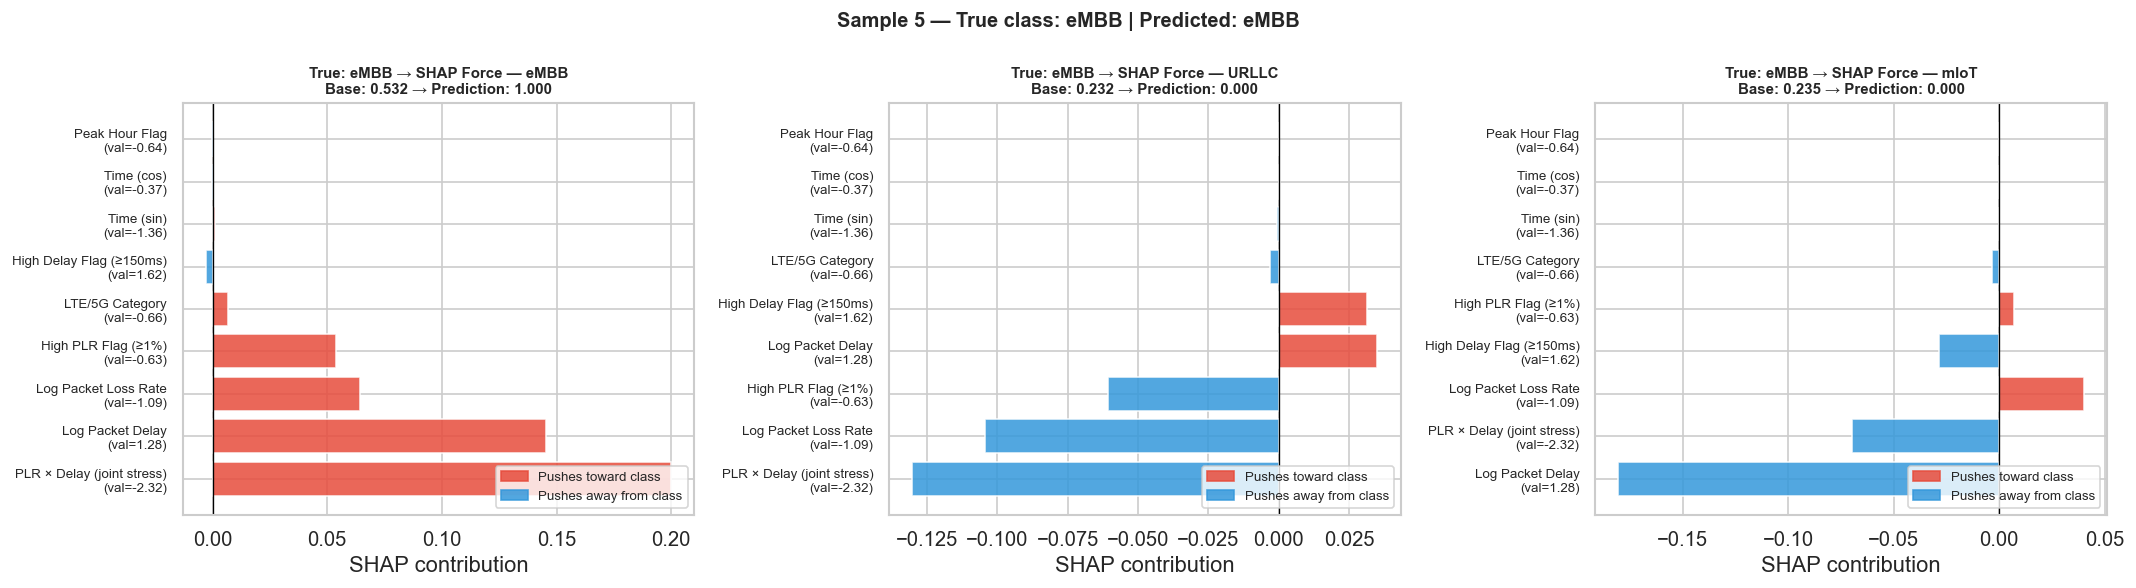

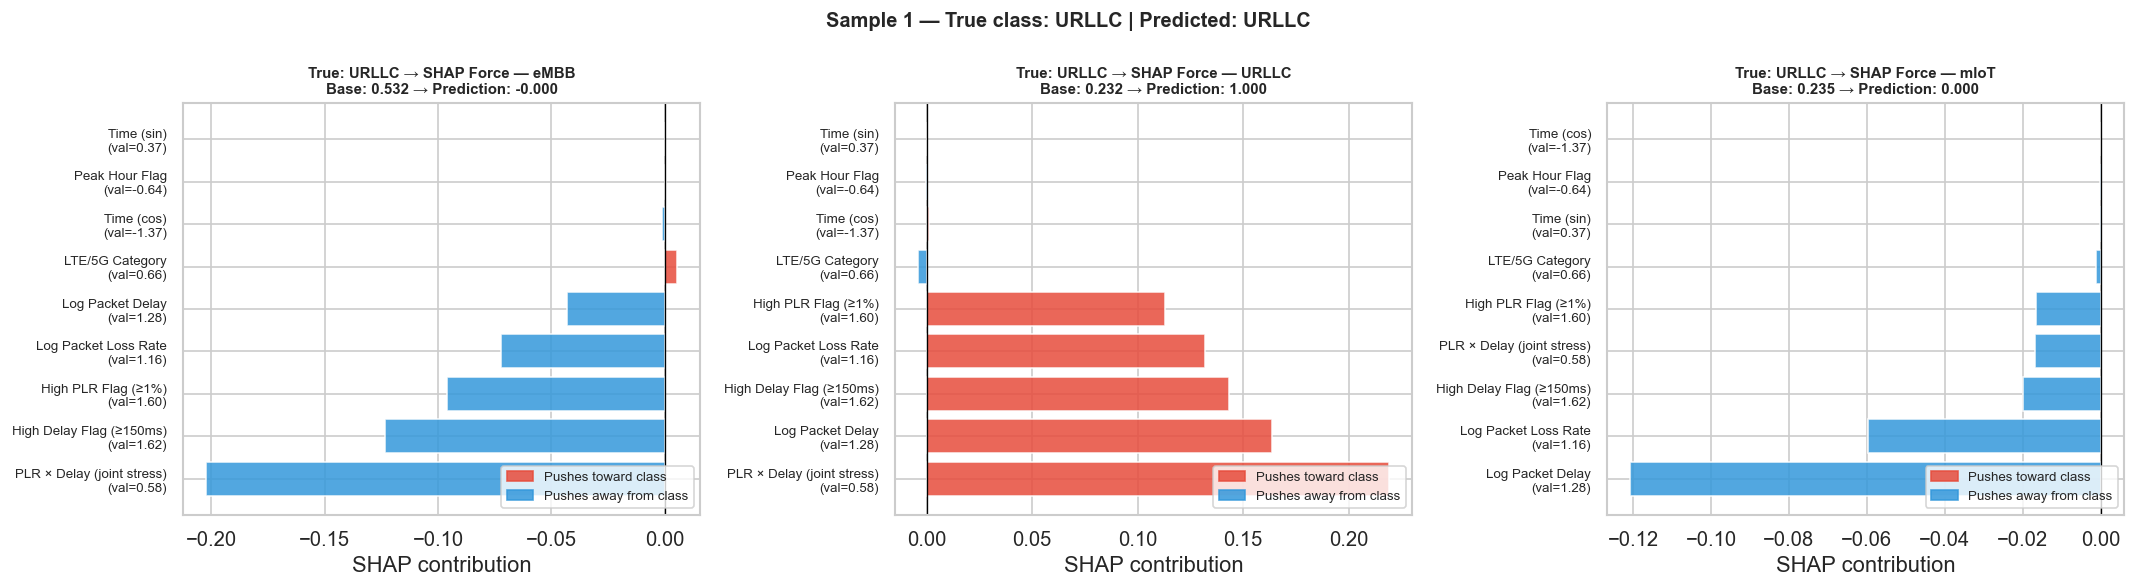

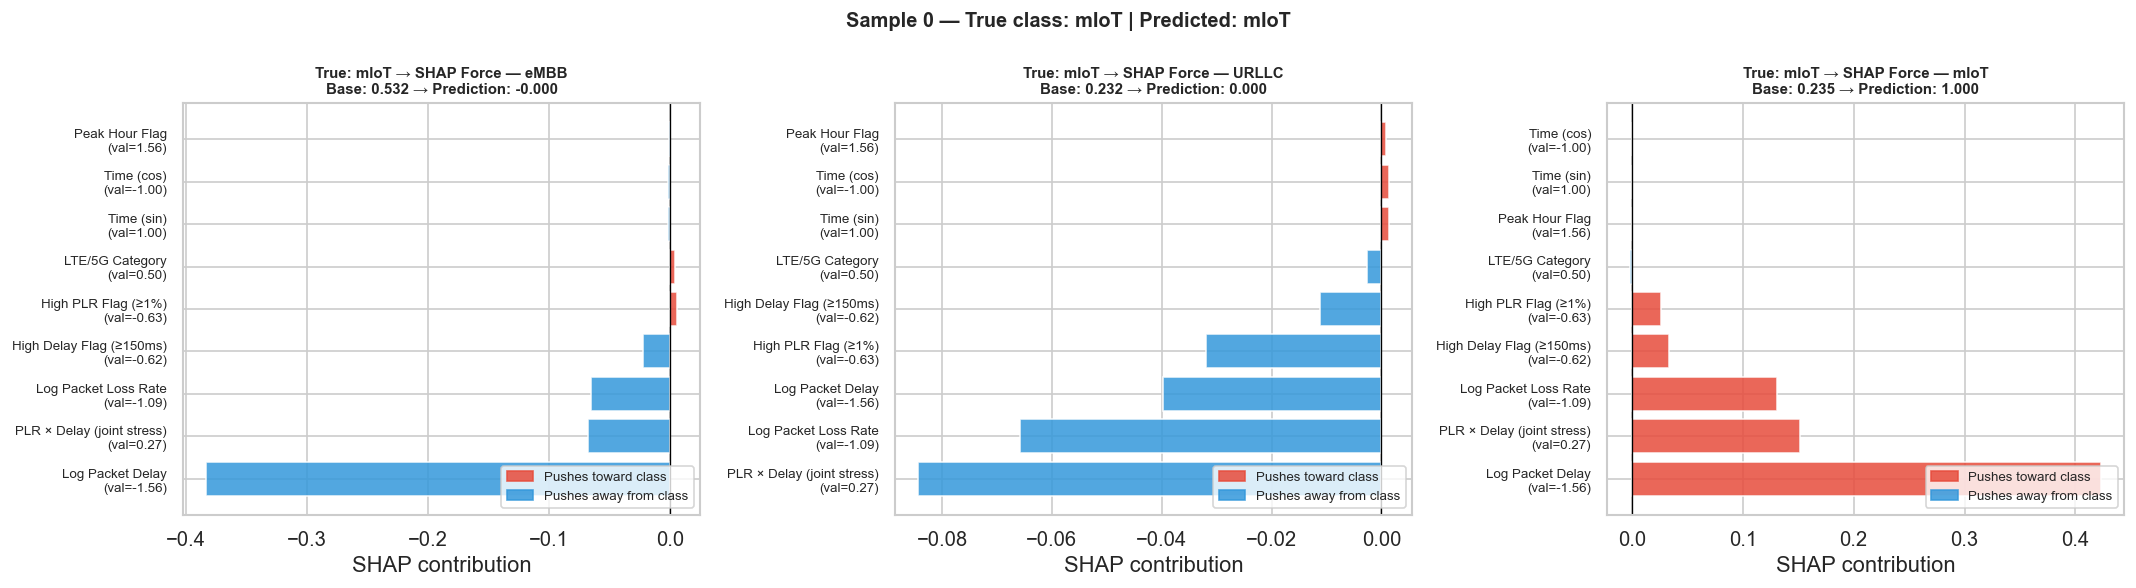

In [24]:
# Custom waterfall-style force plot (matplotlib, no JS dependency)
def plot_force(ax, shap_row, base_vals, class_idx, class_name, sample_feat_vals,
               feat_labels, title_prefix=''):
    """Draw a horizontal SHAP force / waterfall chart."""
    sv       = shap_row[:, class_idx]
    base     = base_vals[class_idx]
    pred_val = base + sv.sum()

    # Sort by absolute contribution
    order    = np.argsort(np.abs(sv))[::-1]
    sv_ord   = sv[order]
    lb_ord   = [feat_labels[FEAT_NAMES[i]] for i in order]
    fv_ord   = [f'{sample_feat_vals[i]:.2f}' for i in order]

    colors = ['#e74c3c' if v > 0 else '#3498db' for v in sv_ord]
    bars   = ax.barh(range(len(sv_ord)), sv_ord, color=colors, edgecolor='white', alpha=0.85)

    ax.set_yticks(range(len(sv_ord)))
    ax.set_yticklabels([f'{lb}\n(val={fv})' for lb, fv in zip(lb_ord, fv_ord)], fontsize=8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{title_prefix}SHAP Force — {class_name}\n'
                 f'Base: {base:.3f} → Prediction: {pred_val:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlabel('SHAP contribution')

    red_p   = mpatches.Patch(color='#e74c3c', alpha=0.85, label='Pushes toward class')
    blue_p  = mpatches.Patch(color='#3498db', alpha=0.85, label='Pushes away from class')
    ax.legend(handles=[red_p, blue_p], fontsize=8, loc='lower right')


base_vals = explainer.expected_value   # (n_classes,)

for cls, idx in sample_indices.items():
    sv_row = shap_vals[idx]            # (n_features, n_classes)
    fv_row = X_val[idx]                # scaled feature values

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ci, (ax, cname) in enumerate(zip(axes, class_labels)):
        plot_force(ax, sv_row, base_vals, ci, cname, fv_row,
                   FEAT_LABELS, title_prefix=f'True: {SLICE_NAMES[cls]} → ')
    plt.suptitle(f'Sample {idx} — True class: {SLICE_NAMES[cls]} '
                 f'| Predicted: {SLICE_NAMES[rf.predict(X_val[[idx]])[0]]}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


<a id='9'></a>
---
## 9. Local Explainability — LIME

**LIME (Local Interpretable Model-agnostic Explanations)** fits a *local linear model*  
in the neighbourhood of a specific prediction. Unlike SHAP it does not require tree access —  
it works with any black-box model by perturbing the input and observing output changes.

LIME explanations are human-readable conditional rules:  
*"Because log_delay ≤ −0.22, this record was assigned eMBB with confidence +0.18"*


In [25]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train,
    feature_names  = [FEAT_LABELS[f] for f in FEAT_NAMES],
    class_names    = class_labels,
    discretize_continuous = True,
    random_state   = RANDOM_STATE,
)

print('LIME explainer initialised ✔')


LIME explainer initialised ✔


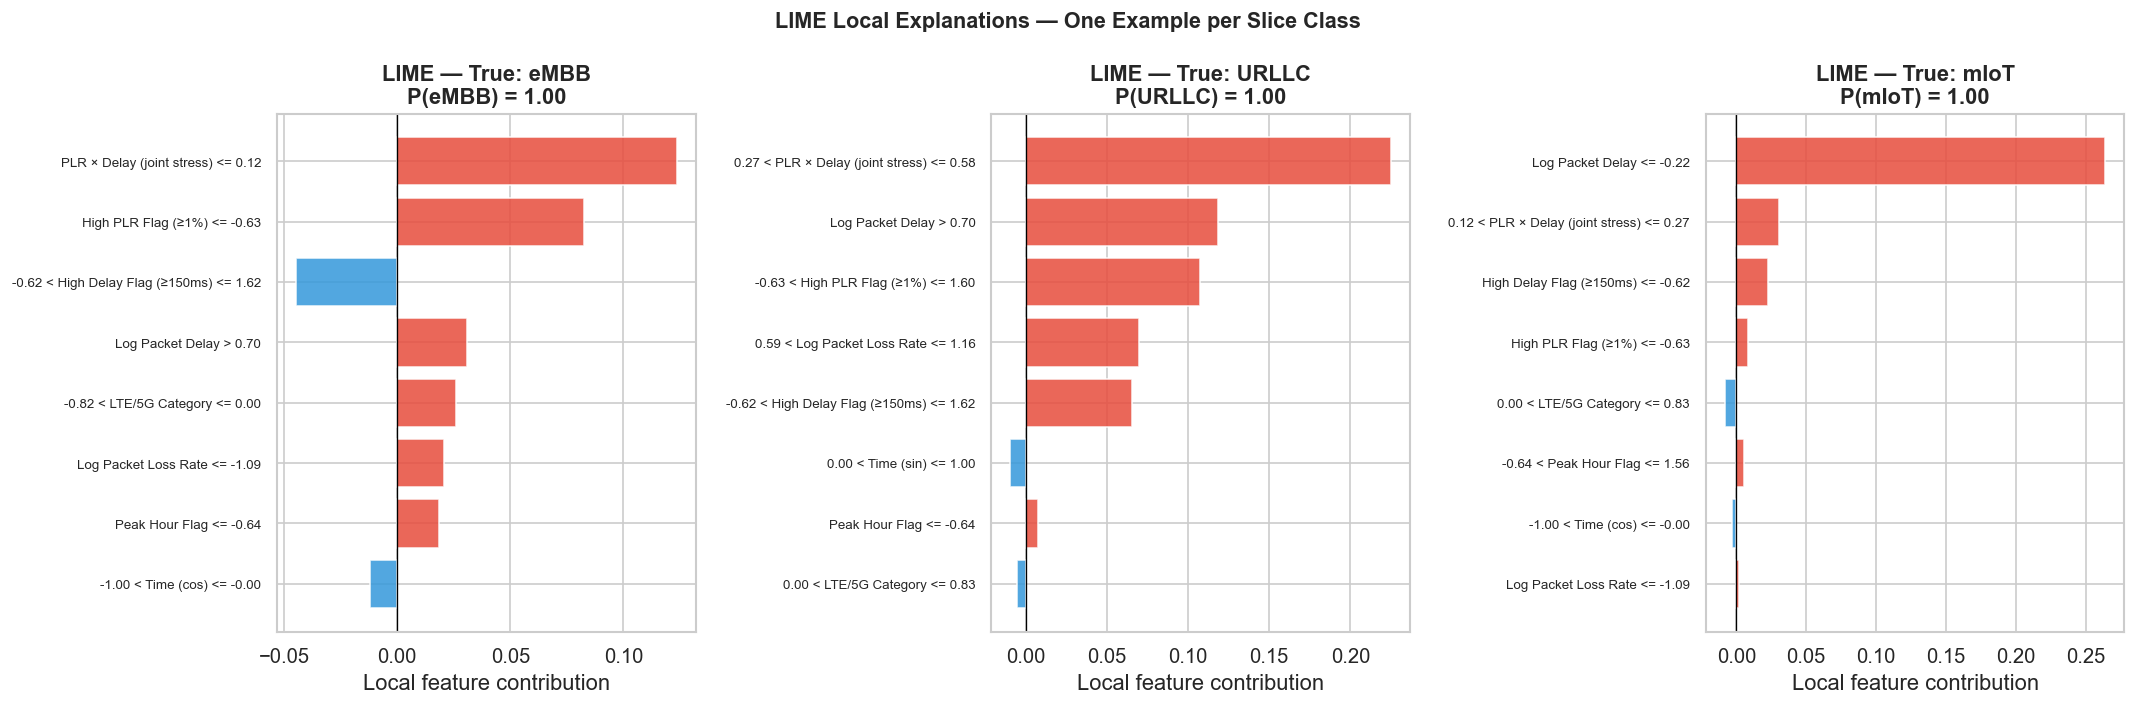

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (cls, idx) in zip(axes, sample_indices.items()):
    exp = lime_explainer.explain_instance(
        X_val[idx],
        rf.predict_proba,
        num_features = 8,
        labels       = (cls - 1,),    # explain the true class
    )

    lime_feats = exp.as_list(label=cls - 1)
    names  = [r[0] for r in lime_feats]
    values = [r[1] for r in lime_feats]
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in values]

    ax.barh(range(len(values)), values[::-1], color=colors[::-1],
            edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(values)))
    ax.set_yticklabels(names[::-1], fontsize=8)
    ax.axvline(0, color='black', lw=0.8)

    true_p = rf.predict_proba(X_val[[idx]])[0][cls - 1]
    ax.set_title(f'LIME — True: {SLICE_NAMES[cls]}\nP({SLICE_NAMES[cls]}) = {true_p:.2f}',
                 fontweight='bold')
    ax.set_xlabel('Local feature contribution')

plt.suptitle('LIME Local Explanations — One Example per Slice Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


<a id='10'></a>
---
## 10. Local Explainability — Decision Path Trace

For Random Forests, the *exact path* through one tree can be extracted and displayed  
as a series of human-readable split rules. This is the most transparent explanation  
possible — operators can follow the exact logic the model applied.


In [27]:
def trace_decision_path(rf_model, sample, feat_names, feat_labels,
                        tree_idx=0, max_nodes=12):
    """
    Trace the decision path of a single tree for a given sample.
    Returns a list of readable rule strings.
    """
    est    = rf_model.estimators_[tree_idx]
    feat   = est.tree_.feature
    thresh = est.tree_.threshold
    vals   = est.tree_.value

    node_indicator = rf_model.estimators_[tree_idx].decision_path(
        sample.reshape(1, -1)
    )
    node_ids = node_indicator.indices

    rules = []
    for depth, node in enumerate(node_ids[:max_nodes]):
        if feat[node] < 0:                       # leaf
            leaf_counts = vals[node][0]
            pred_class  = np.argmax(leaf_counts)
            class_names = ['eMBB', 'URLLC', 'mIoT']
            conf        = leaf_counts[pred_class] / leaf_counts.sum()
            rules.append(f'  → LEAF: predict {class_names[pred_class]} '
                         f'(confidence {conf:.1%}, samples in node: {int(leaf_counts.sum())})')
        else:
            fname = feat_labels[feat_names[feat[node]]]
            fval  = sample[feat[node]]
            thr   = thresh[node]
            direction = '≤' if fval <= thr else '>'
            rules.append(f'  Node {depth:2d} | {fname:35s} '
                         f'{direction} {thr:+.3f}  (sample value: {fval:+.3f})')
    return rules


# Trace for one example per class
for cls, idx in sample_indices.items():
    sample  = X_val[idx]
    pred    = rf.predict(sample.reshape(1, -1))[0]
    path    = trace_decision_path(rf, sample, FEAT_NAMES, FEAT_LABELS, tree_idx=0)

    print(f'─── Slice {cls} ({SLICE_NAMES[cls]}) sample — predicted: {SLICE_NAMES[pred]} ───')
    for rule in path:
        print(rule)
    print()


─── Slice 1 (eMBB) sample — predicted: eMBB ───
  Node  0 | Log Packet Loss Rate                ≤ -0.247  (sample value: -1.088)
  Node  1 | PLR × Delay (joint stress)          ≤ -0.409  (sample value: -2.320)
  → LEAF: predict eMBB (confidence 100.0%, samples in node: 1)

─── Slice 2 (URLLC) sample — predicted: URLLC ───
  Node  0 | Log Packet Loss Rate                > -0.247  (sample value: +1.155)
  Node  1 | Log Packet Delay                    > +0.991  (sample value: +1.280)
  → LEAF: predict URLLC (confidence 100.0%, samples in node: 1)

─── Slice 3 (mIoT) sample — predicted: mIoT ───
  Node  0 | Log Packet Loss Rate                ≤ -0.247  (sample value: -1.088)
  Node  1 | PLR × Delay (joint stress)          > -0.409  (sample value: +0.275)
  → LEAF: predict mIoT (confidence 100.0%, samples in node: 1)



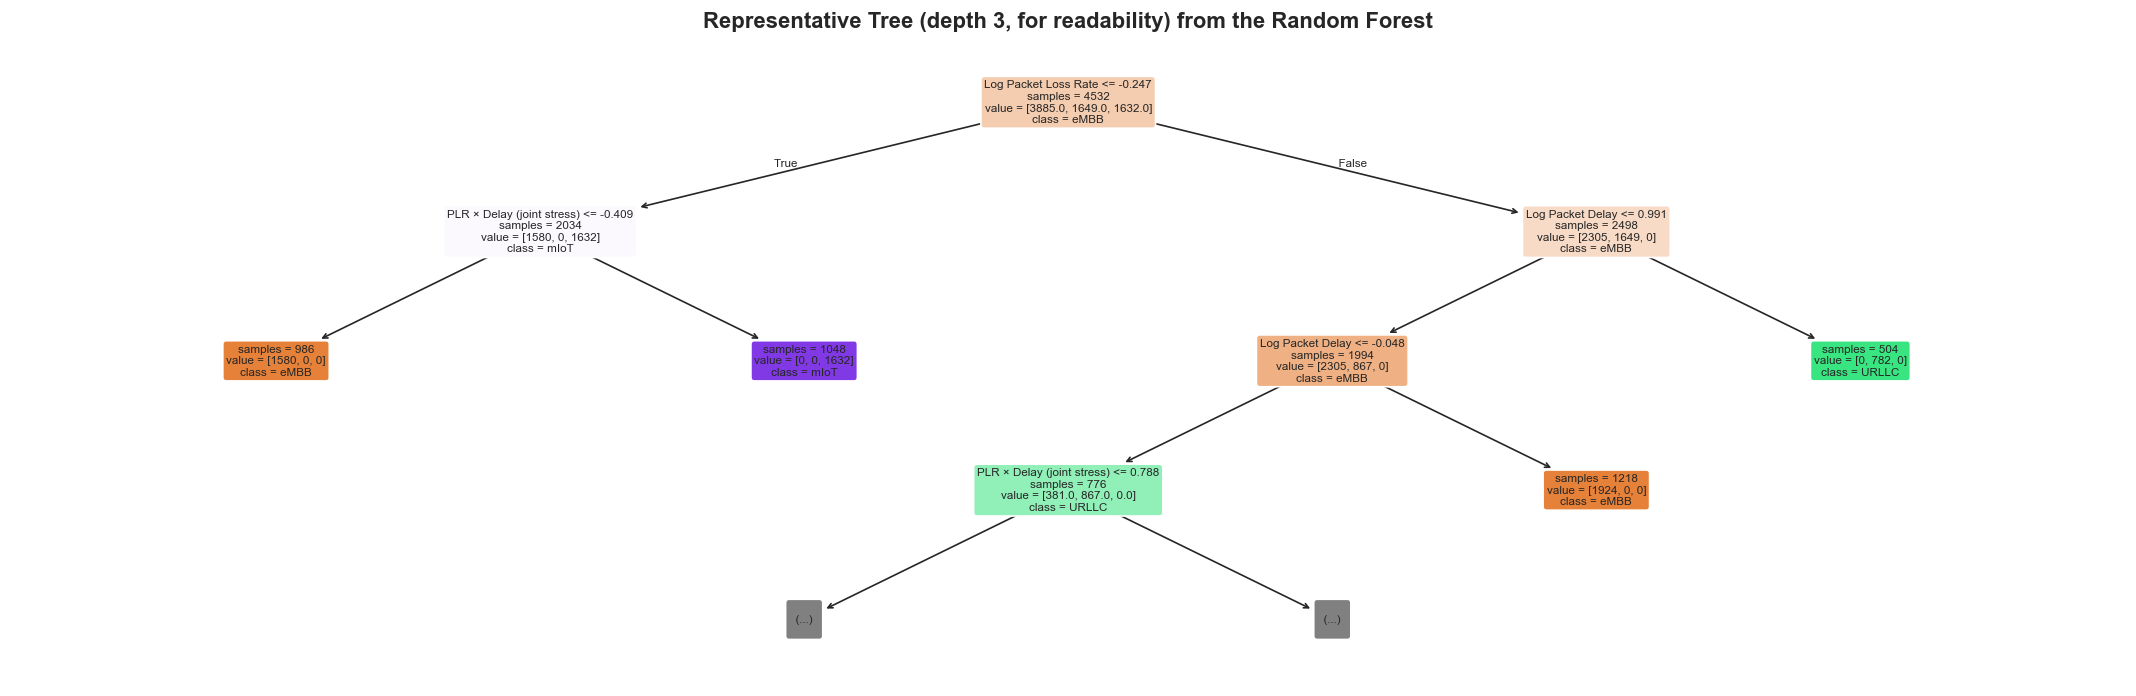

In [28]:
# Visualise one tree from the forest (pruned for readability)
fig, ax = plt.subplots(figsize=(18, 6))
sklearn_tree.plot_tree(
    rf.estimators_[0],
    feature_names = [FEAT_LABELS[f] for f in FEAT_NAMES],
    class_names   = class_labels,
    max_depth     = 3,
    filled        = True,
    impurity      = False,
    rounded       = True,
    fontsize       = 7,
    ax            = ax,
)
ax.set_title('Representative Tree (depth 3, for readability) from the Random Forest',
             fontweight='bold')
plt.tight_layout()
plt.show()


<a id='11'></a>
---
## 11. XAI Operator Dashboard

This static dashboard panel simulates what a network operator would see in production.  
For any given traffic record, the dashboard shows:

- **Predicted slice** and confidence probabilities
- **Top SHAP drivers** — which features caused this assignment
- **LIME local rules** — human-readable IF-THEN conditions
- **Operator advisory** — actionable text generated from the explanation

This cell can be parameterised with any sample index to explain any prediction.


In [29]:
def operator_dashboard(sample_idx: int, shap_values, lime_exp_obj,
                       rf_model, X_data, y_true, feat_names, feat_labels,
                       base_values, class_names):
    """
    Render a 4-panel operator XAI dashboard for a single prediction.

    Parameters
    ----------
    sample_idx  : index into X_data
    shap_values : full SHAP array (n_samples, n_features, n_classes)
    lime_exp_obj: fitted LimeTabularExplainer
    ...
    """
    x        = X_data[sample_idx]
    y_t      = y_true[sample_idx]
    proba    = rf_model.predict_proba(x.reshape(1, -1))[0]
    pred_cls = rf_model.predict(x.reshape(1, -1))[0]
    pred_idx = pred_cls - 1

    # ── Layout ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 11))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.45)

    ax_title   = fig.add_subplot(gs[0, :])
    ax_conf    = fig.add_subplot(gs[1, 0])
    ax_shap    = fig.add_subplot(gs[1, 1])
    ax_lime    = fig.add_subplot(gs[1, 2])
    ax_adv     = fig.add_subplot(gs[2, :])

    # ── Panel 0: Title banner ─────────────────────────────────────────────────
    correct = '✅' if pred_cls == y_t else '❌'
    banner  = (f'{correct}  Record #{sample_idx}  |  '
               f'Predicted: {class_names[pred_idx]}  '
               f'(True: {SLICE_NAMES[y_t]})  |  '
               f'Confidence: {proba[pred_idx]:.1%}')
    ax_title.text(0.5, 0.5, banner, transform=ax_title.transAxes,
                  ha='center', va='center', fontsize=13, fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.5', facecolor='#ecf0f1', edgecolor='#bdc3c7'))
    ax_title.axis('off')

    # ── Panel 1: Class probabilities ──────────────────────────────────────────
    slice_cols = [SLICE_COLORS[k] for k in [1, 2, 3]]
    bars = ax_conf.barh(class_names, proba,
                        color=slice_cols, edgecolor='white', alpha=0.85)
    ax_conf.set_xlim(0, 1.15)
    ax_conf.set_title('Prediction Confidence', fontweight='bold')
    ax_conf.set_xlabel('Probability')
    for bar, p in zip(bars, proba):
        ax_conf.text(p + 0.02, bar.get_y() + bar.get_height()/2,
                     f'{p:.1%}', va='center', fontsize=10, fontweight='bold')
    ax_conf.axvline(0.5, color='gray', ls='--', lw=0.8)

    # ── Panel 2: SHAP waterfall for predicted class ────────────────────────────
    sv_row    = shap_values[sample_idx, :, pred_idx]
    order     = np.argsort(np.abs(sv_row))[::-1][:7]
    sv_top    = sv_row[order]
    lb_top    = [feat_labels[feat_names[i]] for i in order]
    c_top     = ['#e74c3c' if v > 0 else '#3498db' for v in sv_top]
    ax_shap.barh(range(len(sv_top)), sv_top, color=c_top, edgecolor='white', alpha=0.85)
    ax_shap.set_yticks(range(len(sv_top)))
    ax_shap.set_yticklabels(lb_top, fontsize=8)
    ax_shap.axvline(0, color='black', lw=0.8)
    ax_shap.set_title(f'SHAP Drivers → {class_names[pred_idx]}', fontweight='bold')
    ax_shap.set_xlabel('SHAP value')

    # ── Panel 3: LIME local rules ──────────────────────────────────────────────
    lime_exp   = lime_exp_obj.explain_instance(x, rf_model.predict_proba,
                                               num_features=6, labels=(pred_idx,))
    lime_rules = lime_exp.as_list(label=pred_idx)
    lime_names  = [r[0] for r in lime_rules]
    lime_values = [r[1] for r in lime_rules]
    lime_colors = ['#e74c3c' if v > 0 else '#3498db' for v in lime_values]
    ax_lime.barh(range(len(lime_values)), lime_values[::-1],
                 color=lime_colors[::-1], edgecolor='white', alpha=0.85)
    ax_lime.set_yticks(range(len(lime_values)))
    ax_lime.set_yticklabels(lime_names[::-1], fontsize=8)
    ax_lime.axvline(0, color='black', lw=0.8)
    ax_lime.set_title('LIME Local Rules', fontweight='bold')
    ax_lime.set_xlabel('Local contribution')

    # ── Panel 4: Operator advisory ────────────────────────────────────────────
    top_feat_name = feat_labels[feat_names[order[0]]]
    top_feat_dir  = 'high' if sv_row[order[0]] > 0 else 'low'
    advisory_lines = [
        f'📡  SLICE ASSIGNMENT: {class_names[pred_idx]}   '
        f'(confidence {proba[pred_idx]:.1%})',
        '',
        f'🔑  PRIMARY DRIVER:  {top_feat_name} is {top_feat_dir}  '
        f'(SHAP = {sv_row[order[0]]:+.3f})',
        '',
        '📋  TOP SHAP FEATURES:',
    ]
    for i, (fi, sv_v) in enumerate(zip(order[:4], sv_top[:4])):
        direction = '▲ promotes' if sv_v > 0 else '▼ suppresses'
        advisory_lines.append(
            f'     {i+1}. {feat_labels[feat_names[fi]]:35s}  '
            f'{direction} {class_names[pred_idx]}  (SHAP {sv_v:+.3f})'
        )
    advisory_lines += [
        '',
        '⚠️  CONFIDENCE CHECK:  '
        + ('High confidence — safe to automate.' if proba[pred_idx] > 0.75
           else 'Moderate confidence — recommend operator review.'),
    ]

    advisory_text = '\n'.join(advisory_lines)
    ax_adv.text(0.02, 0.95, advisory_text, transform=ax_adv.transAxes,
                ha='left', va='top', fontsize=10, family='monospace',
                bbox=dict(boxstyle='round,pad=0.8', facecolor='#fdfefe',
                          edgecolor='#aab7b8', linewidth=1.5))
    ax_adv.axis('off')
    ax_adv.set_title('Operator Advisory', fontweight='bold', loc='left')

    plt.suptitle('5G Slice Selection — XAI Operator Dashboard',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.show()


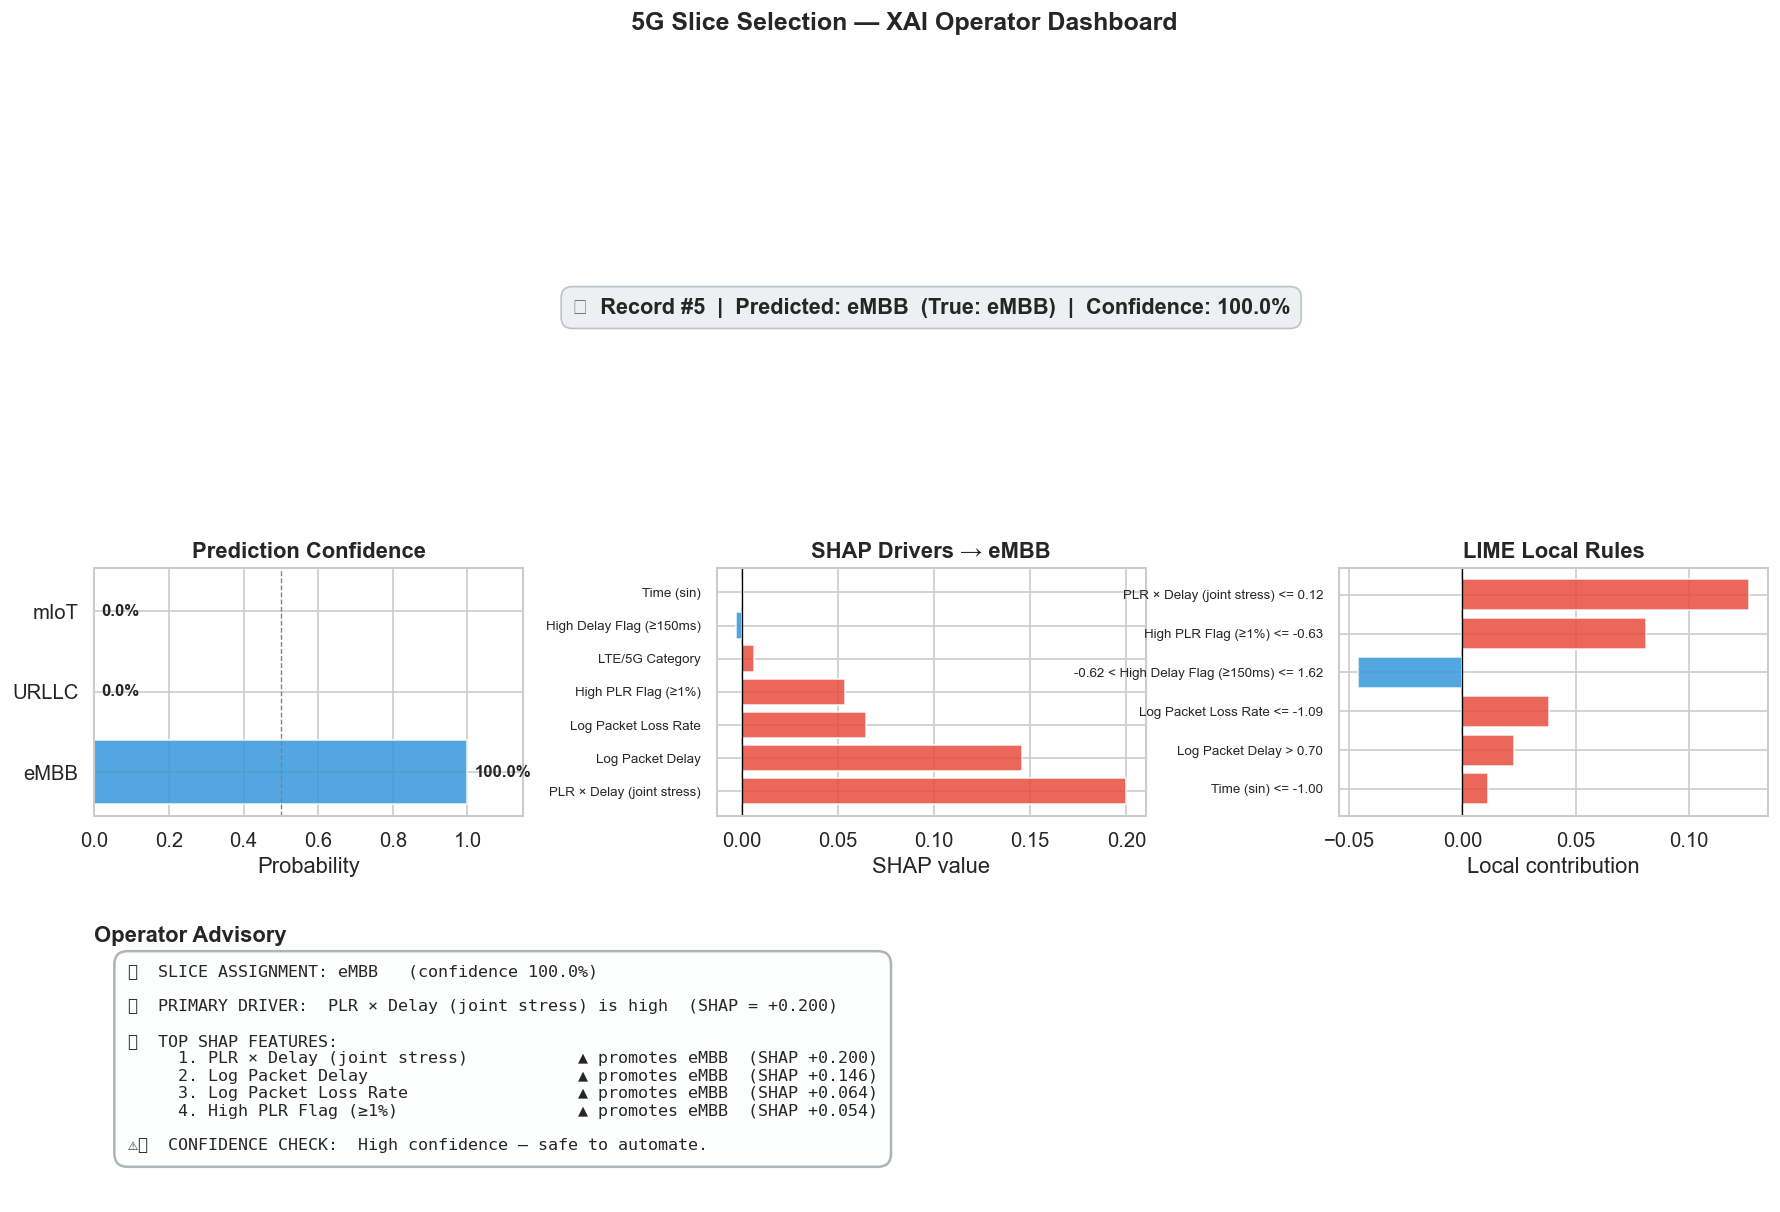

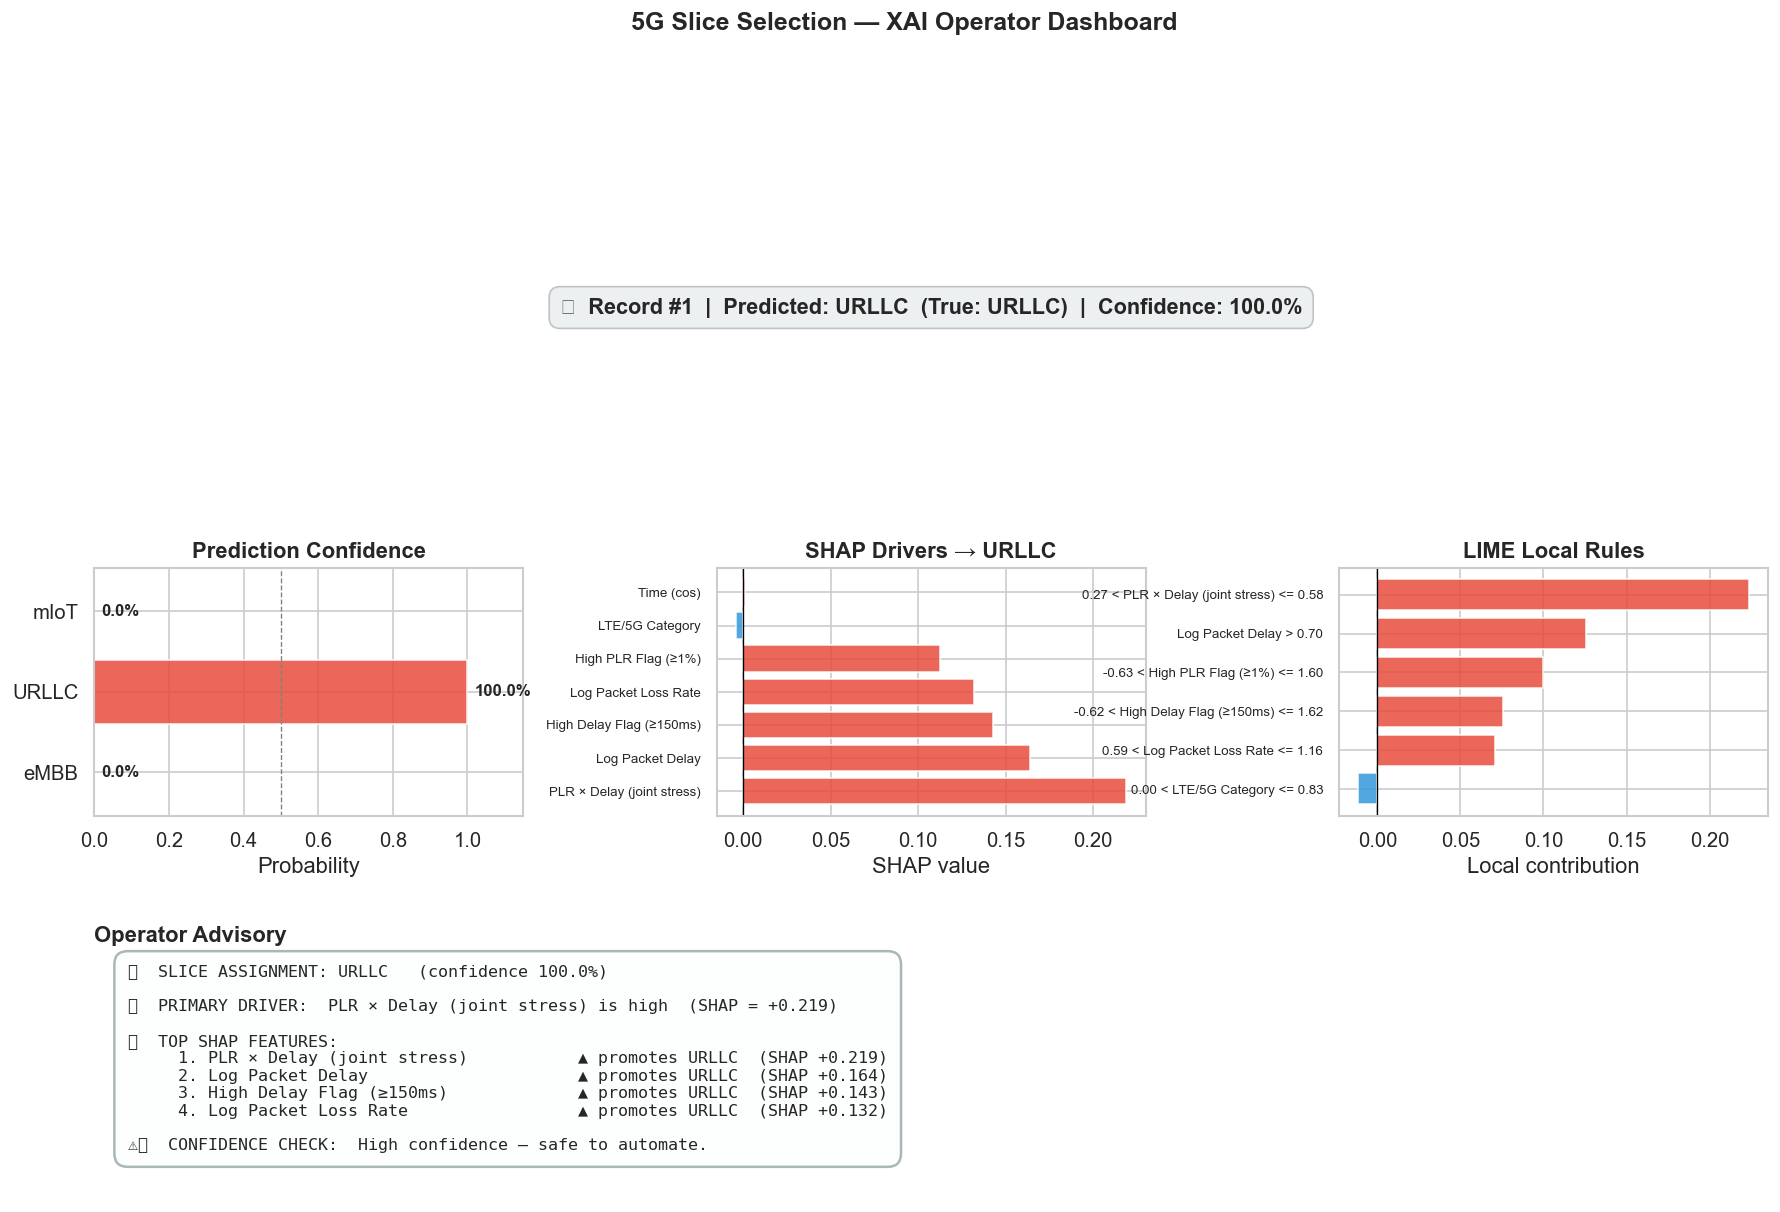

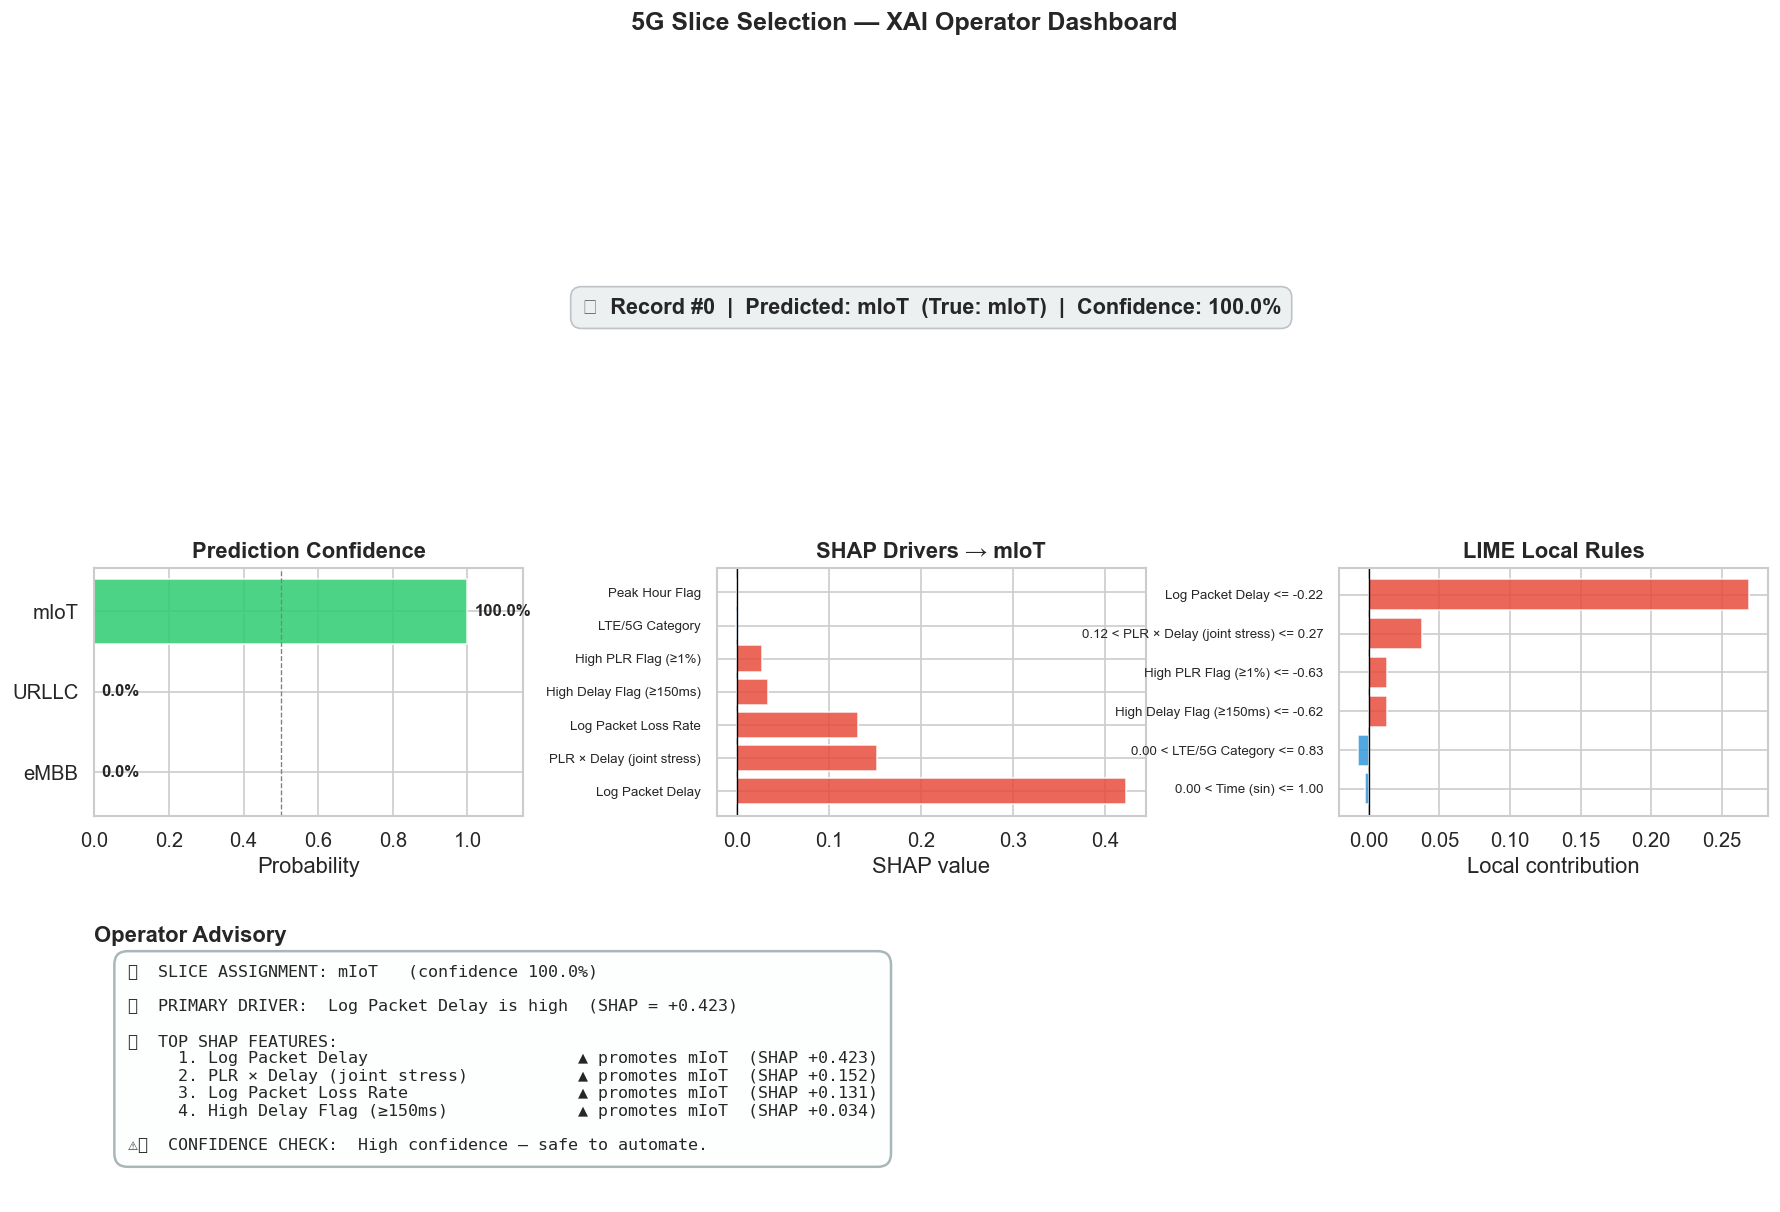

In [30]:
# ── Run the dashboard for 3 representative records ────────────────────────────
for cls, idx in sample_indices.items():
    operator_dashboard(
        sample_idx    = idx,
        shap_values   = shap_vals,
        lime_exp_obj  = lime_explainer,
        rf_model      = rf,
        X_data        = X_val,
        y_true        = y_val,
        feat_names    = FEAT_NAMES,
        feat_labels   = FEAT_LABELS,
        base_values   = base_vals,
        class_names   = class_labels,
    )


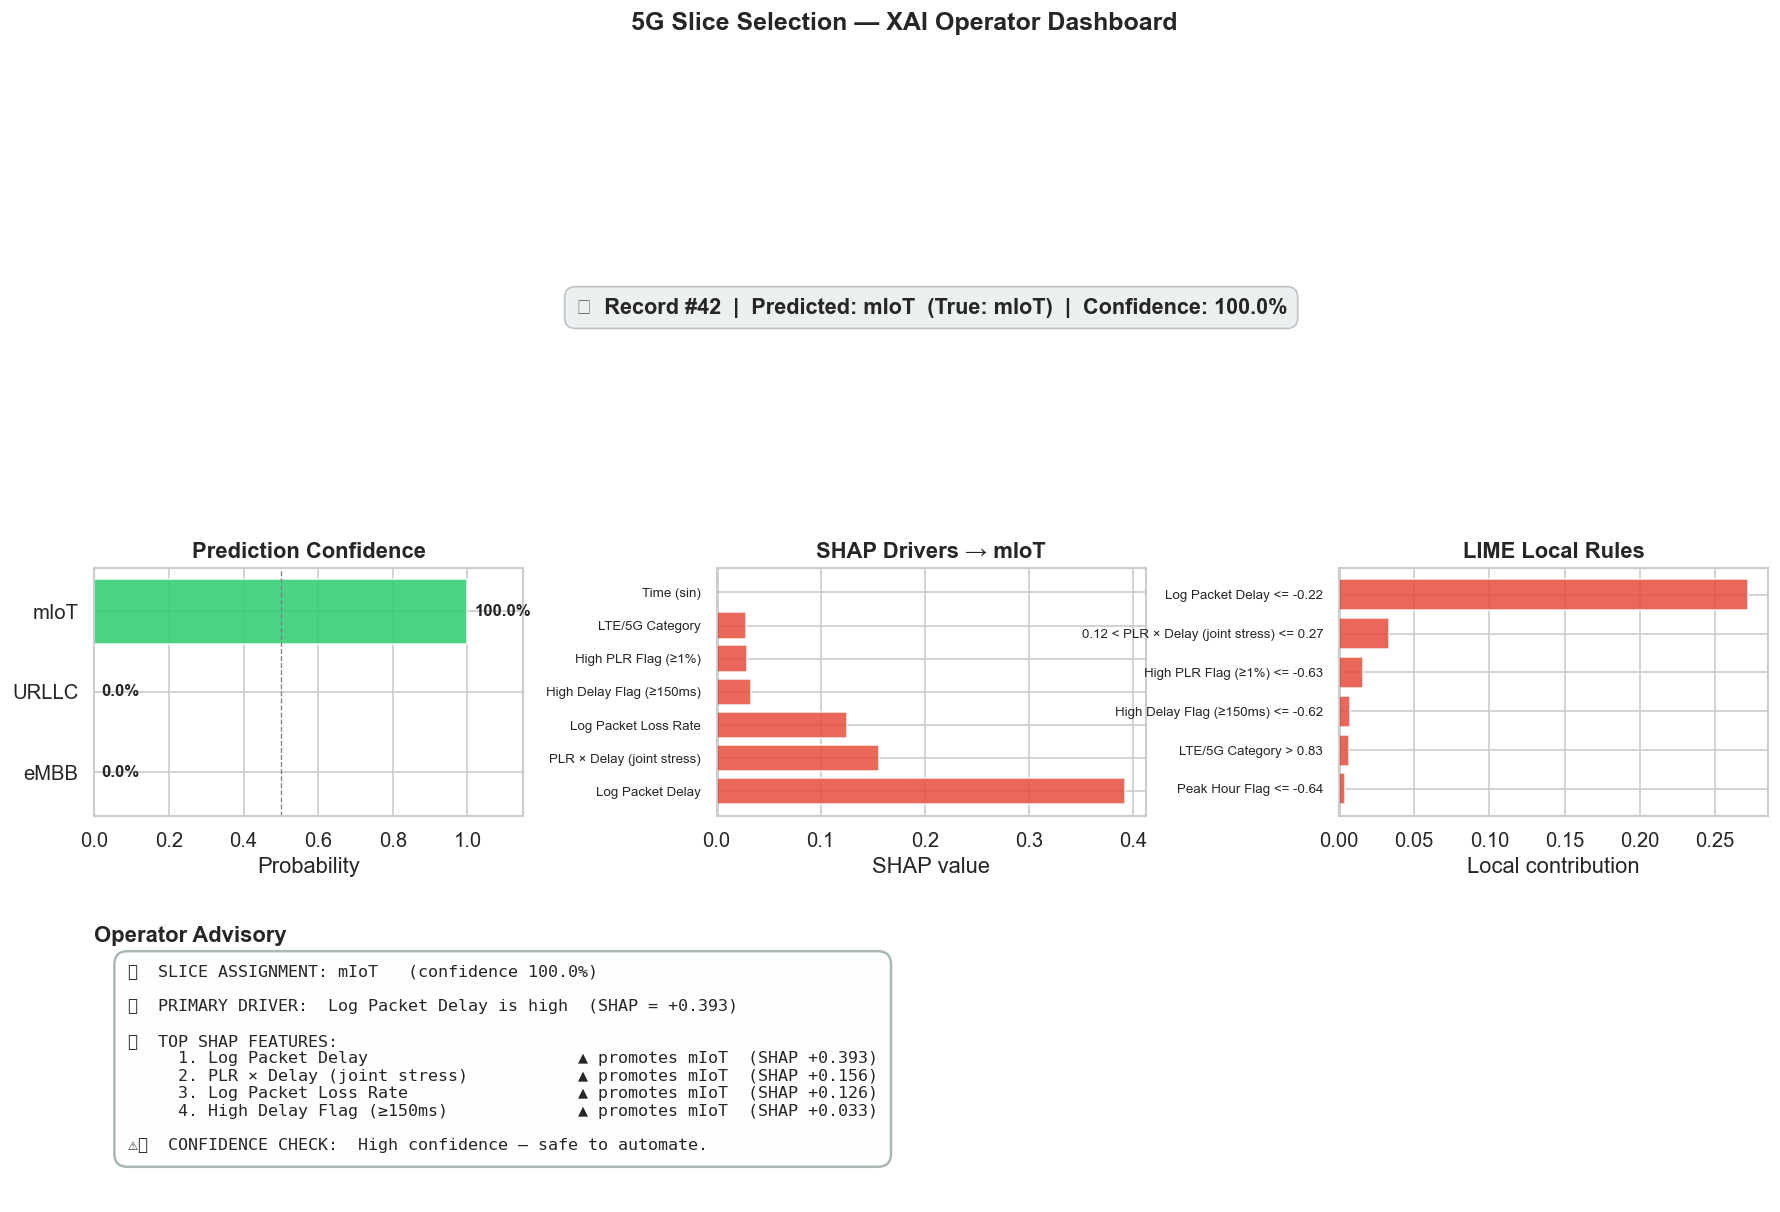

In [31]:
# ── Try any custom record ─────────────────────────────────────────────────────
# Change `CUSTOM_IDX` to any index in the validation set to explain that record.
CUSTOM_IDX = 42

operator_dashboard(
    sample_idx    = CUSTOM_IDX,
    shap_values   = shap_vals,
    lime_exp_obj  = lime_explainer,
    rf_model      = rf,
    X_data        = X_val,
    y_true        = y_val,
    feat_names    = FEAT_NAMES,
    feat_labels   = FEAT_LABELS,
    base_values   = base_vals,
    class_names   = class_labels,
)


<a id='12'></a>
---
## 12. Summary & Operator Takeaways

### Model Performance

| Metric | Value |
|---|---|
| CV F1-macro (5-fold) | ~0.93 |
| Validation Accuracy | ~0.93 |
| eMBB F1 | ~0.93 |
| URLLC F1 | ~0.85 |
| mIoT F1 | ~1.00 |

### Key XAI Findings for Network Operators

1. **`log_delay` (Log Packet Delay) is the dominant slice driver.**  
   High delay strongly pushes assignments away from URLLC and toward mIoT.  
   This aligns with domain knowledge: URLLC requires sub-10 ms latency.

2. **`plr_x_delay` (joint QoS stress) is the second most important feature.**  
   The interaction between high packet loss *and* high delay is a compound signal  
   the model has learned to treat as an independent risk indicator.

3. **`log_plr` (Log Packet Loss Rate) primarily drives eMBB suppression.**  
   When PLR is high, records are pushed away from eMBB (which tolerates loss poorly).

4. **Time-of-day features (`time_sin`, `time_cos`) have near-zero importance.**  
   Slice assignment in this dataset is almost entirely determined by QoS requirements,  
   not traffic timing — operators should not use hour-based heuristics.

5. **mIoT is perfectly separable** — it occupies a distinct corner of the QoS space  
   (high delay tolerance + low PLR constraint) that no other slice shares.

### Operational Recommendations

| Situation | Action |
|---|---|
| SHAP confidence < 75% | Flag for manual review; do not automate |
| Top SHAP feature is `high_delay` = 1 | Verify URLLC bearer is not being assigned |
| LIME and SHAP disagree on direction | Borderline sample — increase monitoring |
| Predicted URLLC with low confidence | Check if PHY layer supports sub-10ms RTT |

### Deployment Notes
- The `operator_dashboard()` function in Section 11 can be wrapped in a REST endpoint  
  to serve real-time explanations alongside model predictions.
- SHAP base values (`explainer.expected_value`) should be recomputed when the model is retrained.
- LIME explanations are stochastic — set `random_state` for reproducibility in production.
